<div dir="rtl">

<h2 style="text-align: center; color: #2E86C1;">بخش اول سؤال</h2>

</div>

In [ ]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [2]:
import numpy as np

df = pd.read_parquet('../data/Divar_cleaned.parquet')

is_sell = (
    df["cat2_slug"]
    .str.contains("sell", na=False)
    .fillna(False)
    .astype(bool)
)

is_full_credit = (
    (df["inferred_full_credit"] == True)
    .fillna(False)
    .astype(bool)
)

conditions = [is_sell, is_full_credit]

choices = [
    df["price_value"],
    df["transformable_credit"]
]

df["unified_price"] = np.select(
    conditions,
    choices,
    default=df["transformed_credit"]
)

# Replace zero prices with NaN
df["unified_price"] = df["unified_price"].replace(0, np.nan)

# Remove suspicious sale prices from modeling
suspicious_sell_price = (
    is_sell
    & df["price_value"].notna()
    & (df["price_value"] < 100_000_000)
)

df.loc[
    suspicious_sell_price,
    "unified_price"
] = np.nan

print(
    "Suspicious sale prices removed:",
    suspicious_sell_price.sum()
)

print(
    "cover unified_price:",
    df["unified_price"].notna().mean() * 100,
    "%"
)

Suspicious sale prices removed: 16862
cover unified_price: 66.60399981199944 %


<div dir="rtl">

###  ساخت ستون قیمت یکپارچه (`unified_price`)

* **ساخت شرط‌ها:** تعیین دو شرط منطقی Boolean (همراه با ایمن‌سازی نوع داده جهت جلوگیری از خطا) برای تشخیص آگهی‌های **فروشی** (`is_sell`) و **رهن کامل** (`is_full_credit`).
* **ترکیب شرطی داده‌ها:** اعمال `np.select` برای جایگذاری هوشمند قیمت‌ها:
  1. اگر **فروشی** بود ← قیمت فروش (`price_value`)
  2. اگر **رهن کامل** بود ← رهن قابل‌تبدیل (`transformable_credit`)
  3. در غیر این صورت (**رهن و اجاره ترکیبی**) ← ارزش تبدیل‌شده (`transformed_credit`)
* **اصلاح صفرهای مصنوعی:** تبدیل صفرهای پیش‌فرض `np.select` به `NaN` جهت جلوگیری از خراب شدن محاسبات آماری (قیمت ۰ تومان).

* **حذف قیمت‌های فروش مشکوک:** آگهی‌های فروشی با قیمت کمتر از ۱۰۰ میلیون تومان به `NaN` تبدیل شدند، چون چنین قیمتی برای ملک غیرواقعی است و احتمالاً خطای ثبت (مثلاً قیمت هر متر) است. این کار **۱۶٬۸۶۲ آگهی** را از مدل‌سازی خارج کرد.

* **دستاورد اصلی:** با ترکیب سه منبع قیمت، **۶۶.۶٪** از کل آگهی‌ها دارای قیمت یکپارچه‌ی معتبر شدند.

تابع `np.select` شرط‌ها را به‌ترتیب بررسی می‌کند؛ بنابراین **ترتیب شرط‌ها** در لیست اهمیت دارد و به محض صادق بودن اولین شرط، مقدار آن اعمال می‌شود.

</div>

In [3]:
cluster_features = ["unified_price", "location_utm_x", "location_utm_y", "building_size"]

cluster_df = df[cluster_features].dropna().copy()

print("تعداد ردیف قبل از حذف NaN:", len(df))
print("تعداد ردیف بعد از حذف NaN:", len(cluster_df))
print(f"درصد داده‌ی باقی‌مانده: {len(cluster_df) / len(df) * 100:.1f}%")

تعداد ردیف قبل از حذف NaN: 999997
تعداد ردیف بعد از حذف NaN: 421096
درصد داده‌ی باقی‌مانده: 42.1%


<div dir="rtl">

### انتخاب ویژگی‌ها و آماده‌سازی داده برای خوشه‌بندی

* **تعریف ویژگی‌های نهایی:** انتخاب ۴ ویژگی اصلی شامل قیمت یکپارچه (`unified_price`)، موقعیت جغرافیایی (`location_utm_x`, `location_utm_y`) و متراژ (`building_size`). محدود نگه داشتن تعداد ویژگی‌ها برای جلوگیری از **نفرین ابعاد (Curse of Dimensionality)** است.
* **حذف سطرهای دارای داده مفقود (NaN):** جداسازی این ۴ ستون و حذف کامل سطرهایی که حتی یکی از آن‌ها خالی است. دلیل این انتخاب:
  1. الگوریتم KMeans توانایی پردازش مقادیر خالی را ندارد.
  2. **موقعیت مکانی:** پر کردن مختصات با میانگین، ملک را به مرکز هندسی منطقه منتقل می‌کند و «موقعیت غیرواقعی» می‌سازد.
  3. **قیمت و متراژ:** پر کردن با مقدار تقریبی، ملک‌های متفاوت را به یک مقدار مصنوعی واحد می‌برد و ساختار توزیع را تغییر می‌دهد.
  4. **حساسیت به فاصله:** KMeans بر پایه فاصله اقلیدسی کار می‌کند و داده‌ی ساختگی باعث نویز و جابه‌جایی مراکز خوشه‌ها (Centroids) می‌شود.

### نتیجه

از ۹۹۹٬۹۹۷ آگهی، **۴۲۱٬۰۹۶ آگهی (۴۲.۱٪)** هر چهار ویژگی را دارند و وارد خوشه‌بندی می‌شوند. حذف داده به‌جای Impute، روشی امن‌تر است و حجم باقی‌مانده هم برای KMeans کاملاً کافی است.

> ⚠️ **محدودیت:** نتایج خوشه‌بندی فقط برای آگهی‌هایی معتبر است که قیمت، مختصات و متراژ را هر سه ثبت کرده‌اند. پوشش قیمت معتبر در دسته‌ها یکسان نیست: آگهی‌های فروش (`residential-sell` ۹۳٪ و `commercial-sell` ۷۶٪) به‌خوبی پوشش داده شده‌اند، ولی اجاره‌ی مسکونی ۳۷٪ و اجاره‌ی تجاری ۱۵٪ است و اجاره‌ی کوتاه‌مدت (`temporary-rent`) وارد نشده است، چون قیمت شبانه با قیمت فروش و رهن هم‌واحد نیست. بنابراین خوشه‌ها عمدتاً بازار **فروش** را توصیف می‌کنند.
</div>

In [4]:
scaler = StandardScaler()
cluster_df["log_unified_price"] = np.log1p(cluster_df["unified_price"])
cluster_df["log_building_size"] = np.log1p(cluster_df["building_size"])

cluster_features_log = ["log_unified_price", "location_utm_x", "location_utm_y", "log_building_size"]

X_scaled = scaler.fit_transform(cluster_df[cluster_features_log])

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=cluster_features_log)

print(cluster_df["cluster"].value_counts().sort_index())

cluster
0    71133
1    45741
2    48538
3    48185
4    30597
5    94077
6    13587
7    22650
8    31284
9    15304
Name: count, dtype: int64


<div dir="rtl">

### خوشه‌بندی KMeans با نرمال‌سازی لگاریتمی و استانداردسازی

* **کاهش اثر داده‌های پرت (توزیع راست‌چوله):** اعمال تبدیل لگاریتمی (`np.log1p`) روی قیمت و متراژ، مقادیر بسیار بزرگ را فشرده می‌کند و از تسلط داده‌های پرت بر خوشه‌بندی می‌کاهد.

* **هم‌مقیاس‌سازی (`StandardScaler`):** چون KMeans بر «فاصله اقلیدسی» تکیه دارد، هر ۴ ویژگی (قیمت لگاریتمی، متراژ لگاریتمی و مختصات UTM) روی میانگین ۰ و انحراف معیار ۱ تنظیم می‌شوند تا هیچ ویژگی صرفاً به‌خاطر بزرگی عدد خام، بقیه را بی‌اثر نکند.

* **اجرای KMeans:** آموزش مدل روی داده‌ی استانداردشده با ۱۰ خوشه (`n_clusters=10`). پارامتر `n_init=10` الگوریتم را با ۱۰ نقطه‌ی شروع تصادفی اجرا می‌کند و نتیجه‌ای را نگه می‌دارد که کمترین WCSS را دارد.

* **بازگرداندن مراکز:** `inverse_transform` مراکز را از مقیاس استانداردشده به مقیاس لگاریتمی برمی‌گرداند. تبدیل به تومان و متر مربع (با `np.expm1`) هنگام رسم نمودار انجام می‌شود.

* **بررسی توازن خوشه‌ها:** شمارش اعضای هر خوشه برای اطمینان از این‌که یک خوشه بخش غیرعادی بزرگی از داده را نگرفته باشد.

### نتیجه

اندازه‌ی خوشه‌ها بین ۱۳٬۵۸۷ (۳.۲٪) و ۹۴٬۰۷۷ (۲۲.۳٪) از ۴۲۱٬۰۹۶ آگهی است؛ یعنی توزیع نسبتاً متوازن است و هیچ خوشه‌ای بخش غالب داده را نگرفته است. تبدیل لگاریتمی و استانداردسازی دو مشکل اصلی داده‌های املاک را کاهش می‌دهند: چولگی شدید قیمت و متراژ، و اختلاف مقیاس آن‌ها با مختصات مکانی.

> ⚠️ **توجه:** متوازن بودن اندازه‌ی خوشه‌ها به‌تنهایی نشانه‌ی کیفیت بالا نیست. کیفیت جداسازی با Silhouette در بخش بعد سنجیده می‌شود.

</div>

   unified_price  building_size  location_utm_x  location_utm_y
0   7.203238e+09         109.48       515430.61      3959242.94
1   1.326760e+09         172.02       533935.67      3995297.13
2   2.843170e+08          75.76       478154.85      3924861.64
3   2.294866e+09         129.17       521505.12      3453140.59
4   1.745725e+09         114.33      1235661.84      4049471.64
5   2.068627e+09          62.44       508523.65      3952528.49
6   1.636735e+09         141.74      1108017.91      3186402.23
7   2.760698e+10         278.33       514266.88      3928395.56
8   2.416512e+09         113.22       141835.07      4114009.33
9   1.847160e+09         823.89       463511.70      3923115.56


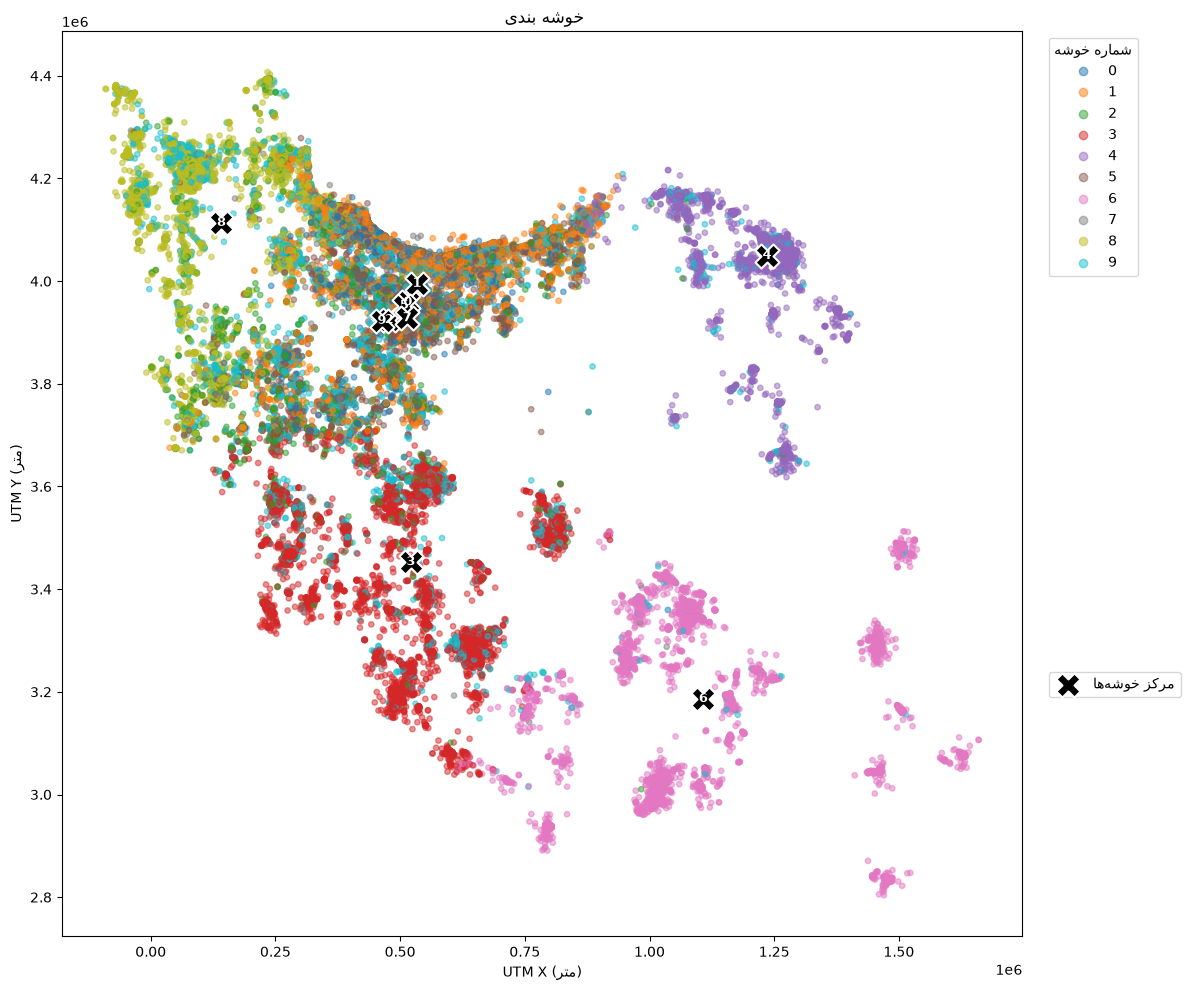

In [5]:
# برگردوندن مراکز به مقیاس اصلی (غیر لگاریتمی)
centers_scaled_back = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_scaled_back, columns=cluster_features_log)

# log_unified_price و log_building_size رو به مقیاس واقعی برگردون
centers_df["unified_price"] = np.expm1(centers_df["log_unified_price"])
centers_df["building_size"] = np.expm1(centers_df["log_building_size"])

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    cluster_df["location_utm_x"],
    cluster_df["location_utm_y"],
    c=cluster_df["cluster"],
    cmap="tab10",
    s=15,
    alpha=0.5,
)

ax.scatter(
    centers_df["location_utm_x"],
    centers_df["location_utm_y"],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidths=1.5,
    label="مرکز خوشه‌ها",
    zorder=5,
)

for i, row in centers_df.iterrows():
    ax.annotate(
        str(i),
        (row["location_utm_x"], row["location_utm_y"]),
        color="white",
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=6,
    )

print(centers_df[["unified_price", "building_size", "location_utm_x", "location_utm_y"]].round(2))

legend1 = ax.legend(*scatter.legend_elements(), title="شماره خوشه", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 0.3))

ax.set_xlabel("UTM X (متر)")
ax.set_ylabel("UTM Y (متر)")
ax.set_title("خوشه بندی ")



plt.tight_layout()
plt.show()

outsite: 3,792 from 421,096


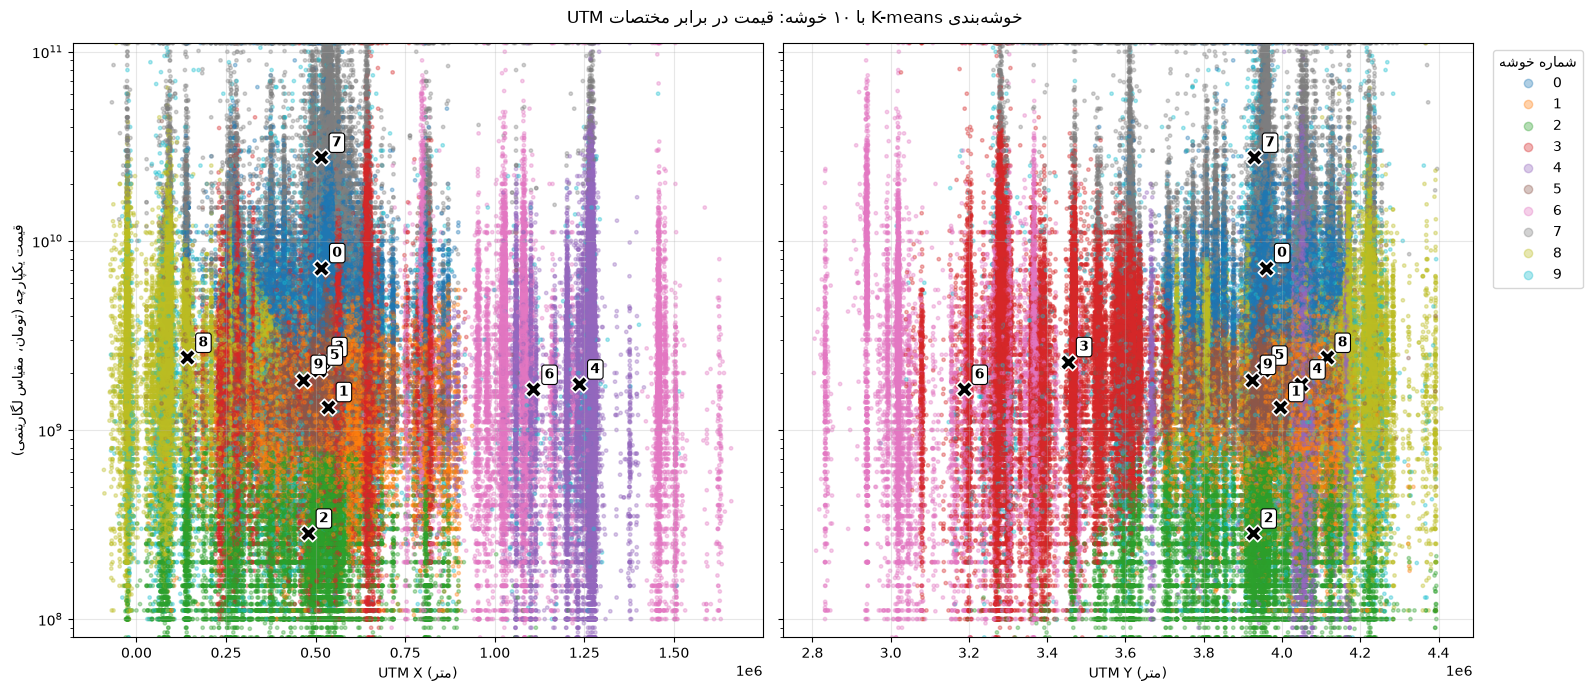

In [6]:
lo, hi = cluster_df["unified_price"].quantile([0.005, 0.995])
outside = ((cluster_df["unified_price"] < lo) | (cluster_df["unified_price"] > hi)).sum()
print(f"outsite: {outside:,} from {len(cluster_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, col, label in zip(
    axes,
    ["location_utm_x", "location_utm_y"],
    ["UTM X (متر)", "UTM Y (متر)"],
):
    sc = ax.scatter(
        cluster_df[col],
        cluster_df["unified_price"],
        c=cluster_df["cluster"],
        cmap="tab10",
        s=6,
        alpha=0.35,
        rasterized=True,
    )
    ax.scatter(
        centers_df[col],
        centers_df["unified_price"],
        c="black",
        marker="X",
        s=140,
        edgecolors="white",
        linewidths=1.2,
        zorder=5,
    )
    for i, row in centers_df.iterrows():
        ax.annotate(
            str(i), (row[col], row["unified_price"]),
            xytext=(8, 8), textcoords="offset points",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.8),
            zorder=7,
        )
    ax.set_yscale("log")
    ax.set_ylim(lo, hi)
    ax.set_xlabel(label)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("قیمت یکپارچه (تومان، مقیاس لگاریتمی)")
axes[1].legend(
    *sc.legend_elements(), title="شماره خوشه",
    loc="upper left", bbox_to_anchor=(1.02, 1),
)
fig.suptitle("خوشه‌بندی K-means با ۱۰ خوشه: قیمت در برابر مختصات UTM")
plt.tight_layout()
plt.show()

<div dir="rtl">

## الف) رسم نمودارهای خوشه‌بندی

* **بازگرداندن مراکز به مقیاس واقعی:** `inverse_transform` مراکز خوشه‌ها را از مقیاس استانداردشده به مقیاس لگاریتمی برمی‌گرداند و سپس `np.expm1` قیمت (تومان) و متراژ (متر مربع) واقعی را می‌دهد. مرکز قیمت در این حالت **میانگین هندسی** قیمت‌های خوشه است، نه میانگین حسابی.
* **نمودار اصلی (قیمت در برابر مختصات UTM):** دو پنل که در هر دو قیمت روی محور عمودی است و محور افقی به‌ترتیب `UTM X` و `UTM Y` است.
  * محور قیمت لگاریتمی است، چون قیمت‌ها از چند میلیون تا چند ده میلیارد تومان پخش‌اند.
  * محدوده‌ی نمایش محور قیمت به صدک ۰.۵ تا ۹۹.۵ محدود شده است. **۳٬۷۹۲ نقطه از ۴۲۱٬۰۹۶ نقطه (حدود ۰.۹٪)** بیرون از این محدوده‌اند و فقط در نمودار دیده نمی‌شوند؛ در خوشه‌بندی حضور دارند.
* **نمودار مکمل (نقشه):** `UTM X` در برابر `UTM Y` برای دیدن پراکندگی جغرافیایی خوشه‌ها.
* **رنگ و مراکز:** در هر دو نمودار، رنگ هر نقطه نشان‌دهنده‌ی خوشه‌ی آن است (پالت ۱۰رنگ `tab10`) و مرکز هر خوشه با علامت `X` مشکی مشخص شده است. در نمودار قیمت، شماره‌ی خوشه کنار `X` و در کادر سفید نوشته شده است.
* **جدول مراکز:** چون مراکز چند خوشه در ناحیه‌ی مرکزی روی نقشه به هم نزدیک‌اند و شماره‌شان خوانا نیست، مقادیر عددی مراکز در جدول جداگانه آمده است.

## ب) علت استفاده از تبدیل لگاریتمی (`np.log1p`)

* **چولگی داده‌ها:** توزیع قیمت و متراژ به سمت راست چوله است. بیشتر املاک قیمت و متراژ معمولی دارند، ولی تعداد محدودی ملک بسیار گران یا بسیار بزرگ وجود دارد.

* **اثر داده‌های پرت:** این مقادیر بزرگ فاصله‌ی اقلیدسی را کج می‌کنند. در اجرای اولیه‌ی ما (بدون لگاریتم)، حدود ۵۸٪ داده در یک خوشه‌ی بزرگ جمع شد.

* **فشرده‌سازی مقیاس:** لگاریتم فاصله‌ی بین مقادیر بزرگ را فشرده می‌کند، در نتیجه املاک معمولی هم در شکل‌گیری خوشه‌ها نقش پیدا می‌کنند و اندازه‌ی خوشه‌ها متوازن‌تر می‌شود.


## ج) تحلیل خروجی خوشه‌بندی


| خوشه | قیمت (میلیارد تومان) | متراژ (متر مربع) | UTM X (کیلومتر) | UTM Y (کیلومتر) | گروه |
| :---: | :---: | :---: | :---: | :---: | :--- |
| ۰ | ۷.۲۰ | ۱۰۹ | ۵۱۵ | ۳٬۹۵۹ | مرکزی |
| ۱ | ۱.۳۳ | ۱۷۲ | ۵۳۴ | ۳٬۹۹۵ | مرکزی |
| ۲ | ۰.۲۸ | ۷۶ | ۴۷۸ | ۳٬۹۲۵ | مرکزی |
| ۳ | ۲.۲۹ | ۱۲۹ | ۵۲۲ | ۳٬۴۵۳ | جداشده بر اساس موقعیت |
| ۴ | ۱.۷۵ | ۱۱۴ | ۱٬۲۳۶ | ۴٬۰۴۹ | جداشده بر اساس موقعیت |
| ۵ | ۲.۰۷ | ۶۲ | ۵۰۹ | ۳٬۹۵۳ | مرکزی |
| ۶ | ۱.۶۴ | ۱۴۲ | ۱٬۱۰۸ | ۳٬۱۸۶ | جداشده بر اساس موقعیت |
| ۷ | ۲۷.۶۱ | ۲۷۸ | ۵۱۴ | ۳٬۹۲۸ | مرکزی |
| ۸ | ۲.۴۲ | ۱۱۳ | ۱۴۲ | ۴٬۱۱۴ | جداشده بر اساس موقعیت |
| ۹ | ۱.۸۵ | ۸۲۴ | ۴۶۴ | ۳٬۹۲۳ | مرکزی |

* **خوشه‌های جداشده بر اساس موقعیت (۳، ۴، ۶ و ۸):** مراکز این خوشه‌ها از هم و از ناحیه‌ی مرکزی دورند (شمال‌غرب، شمال‌شرق، جنوب‌شرق و جنوب‌مرکز)، ولی قیمت (۱.۶ تا ۲.۴ میلیارد) و متراژ (۱۱۳ تا ۱۴۲ متر) آن‌ها به هم نزدیک است. یعنی در این خوشه‌ها **موقعیت جغرافیایی** عامل اصلی تفکیک است.

* **خوشه‌های ناحیه‌ی مرکزی (۰، ۱، ۲، ۵، ۷ و ۹):** مراکز این خوشه‌ها در محدوده‌ی کوچکی قرار دارند (X حدود ۴۶۰ تا ۵۳۵ و Y حدود ۳٬۹۲۰ تا ۳٬۹۹۵ کیلومتر)، ولی قیمت آن‌ها از حدود ۰.۲۸ تا ۲۷.۶ میلیارد و متراژ از حدود ۶۲ تا ۸۲۴ متر مربع تغییر می‌کند. یعنی در ناحیه‌ی پرتراکم که موقعیت‌ها به هم نزدیک است، **قیمت و متراژ** عامل تفکیک خوشه‌ها شده‌اند.

* **جانمایی مراکز:** نزدیک بودن چند مرکز در ناحیه‌ی مرکزی نقشه، به‌دلیل تراکم بالای آگهی‌ها در آن محدوده طبیعی است.

> «در مناطقی که آگهی‌ها از نظر جغرافیایی از هم دورند، خوشه‌بندی املاک را عمدتاً بر اساس **فاصله‌ی مکانی** دسته‌بندی کرده است؛ اما در ناحیه‌ی پرتراکم مرکزی که داده‌ها از نظر جغرافیایی نزدیک‌اند، **قیمت و متراژ** به متغیر اصلی تفکیک خوشه‌ها تبدیل شده‌اند.»

</div>

<div dir="rtl">

<h2 style="text-align: center; color: #2E86C1;">بخش دوم سؤال</h2>

</div>

In [7]:
wcss = []
k_range = range(1, 21)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"k={k:2d} -> WCSS={km.inertia_:,.0f}")

k= 1 -> WCSS=1,684,384
k= 2 -> WCSS=1,346,672
k= 3 -> WCSS=1,088,736
k= 4 -> WCSS=874,706
k= 5 -> WCSS=767,093
k= 6 -> WCSS=694,714
k= 7 -> WCSS=635,956
k= 8 -> WCSS=581,224
k= 9 -> WCSS=545,340
k=10 -> WCSS=512,794
k=11 -> WCSS=487,097
k=12 -> WCSS=465,756
k=13 -> WCSS=445,700
k=14 -> WCSS=426,478
k=15 -> WCSS=411,580
k=16 -> WCSS=397,888
k=17 -> WCSS=386,149
k=18 -> WCSS=373,411
k=19 -> WCSS=363,595
k=20 -> WCSS=351,579


<div dir="rtl">

### اجرای KMeans و محاسبه WCSS برای $k$های ۱ تا ۲۰

* **تعریف بازه ارزیابی:** مقداردهی اولیه بازه هایپرپارامتر $k$ از ۱ تا ۲۰ به همراه تعریف لیست `wcss` جهت ذخیره مقادیر مجموع مربعات فواصل درون‌خوشه‌ای (Within-Cluster Sum of Squares).

* **آموزش متوالی الگوریتم KMeans:** اجرای مدل به ازای هر $k$ روی داده‌های پیش‌پردازش‌شده (`X_scaled`). تنظیم `n_init=10` جهت اطمینان از یافتن بهترین نقطه شروع و `random_state=42` برای تکرارپذیری نتایج.

* **استخراج شاخص Inertia (معادل WCSS):** دریافت مقدار `km.inertia_` در هر ارزیابی و افزودن آن به لیست. این شاخص میزان فشردگی داده‌ها را درون خوشه‌ها نشان می‌دهد و با افزایش $k$ افت می‌کند.

هدف این مرحله، گردآوری مقادیر WCSS به ازای kهای مختلف است تا در گام بعدی، نقطه شکست منحنی که نشان‌دهنده تعادل میان فشردگی خوشه‌ها و پیچیدگی مدل است، شناسایی شود.

</div>

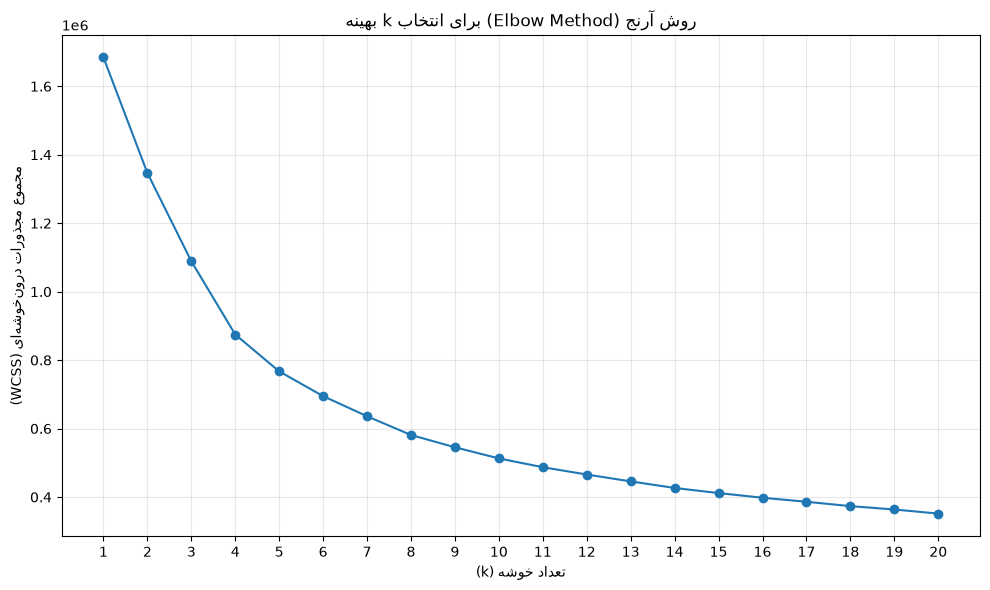

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("تعداد خوشه (k)")
plt.ylabel("مجموع مجذورات درون‌خوشه‌ای (WCSS)")
plt.title("روش آرنج (Elbow Method) برای انتخاب k بهینه")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

### رسم نمودار   (Elbow Method)

* **محورهای نمودار:** رسم مقادیر WCSS (محور عمودی) در برابر تعداد خوشه‌ها $k$ از ۱ تا ۲۰ (محور افقی).

* **نمایش کامل محور افقی (`plt.xticks`):** درج تمام اعداد ۱ تا ۲۰ روی محور $k$ جهت جلوگیری از حذف خودکار مقادیر توسط کتابخانه.

* **تسهیل خوانایی (`plt.grid`):** اضافه کردن خطوط شبکه‌ای کم‌رنگ در پس‌زمینه برای سنجش چشمی دقیق‌تر افت منحنی.

شناسایی بصری نقطه‌ای که منحنی در آن دچار «شکست» یا «آرنج» می‌شود و از آن نقطه به بعد، میزان کاهش WCSS ناچیز می‌گردد.

</div>

best-k = 6


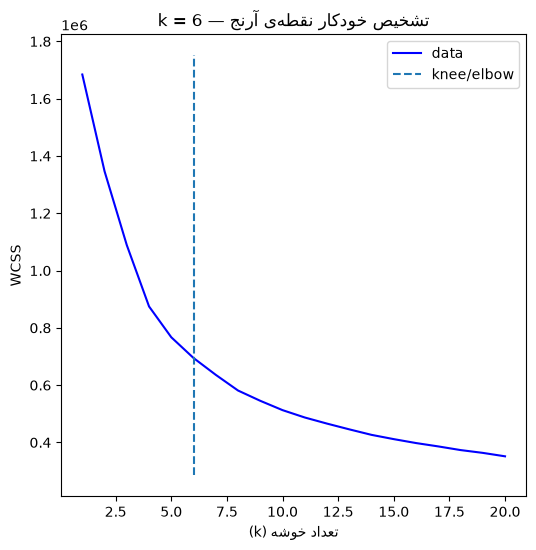

In [18]:
kl = KneeLocator(list(k_range), wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow

print("best-k =", optimal_k)

kl.plot_knee()
plt.title(f"تشخیص خودکار نقطه‌ی آرنج — k = {optimal_k}")
plt.xlabel("تعداد خوشه (k)")
plt.ylabel("WCSS")
plt.show()

<div dir="rtl">

### تشخیص خودکار نقطه‌ی آرنج با الگوریتم ریاضی (KneeLocator)

* **محاسبه دقیق نقطه شکست (`KneeLocator`):** استفاده از کتابخانه `kneed` برای یافتن نقطه آرنج با تحلیل ریاضی انحنای منحنی، به جای اتکا به حدس چشمی.
  * **`curve="convex"`:** تنظیم نوع انحنا به حالت محدب (شکل طبیعی منحنی WCSS).

  * **`direction="decreasing"`:** تنظیم جهت روند نزولی مقادیر WCSS با افزایش $k$.

* **استخراج $k$ بهینه (`optimal_k`):** دریافت عدد پیشنهادی الگوریتم برای تعداد خوشه‌های بهینه.

* **تجسم‌سازی نقطه آرنج (`kl.plot_knee`):** رسم منحنی به همراه یک خط عمودی بر روی $k$ بهینه جهت اعتبارسنجی بصری.

#### 💡 دلیل استفاده از KneeLocator
  `KneeLocator` با محاسبه حداکثر فاصله عمودی نقاط منحنی تا خط واصلِ ابتدا ($k=1$) و انتها ($k=20$)، دقیق‌ترین نقطه انحنا را به صورت ریاضی محاسبه می‌کند.

</div>

k= 2 -> Silhouette=0.3364
k= 3 -> Silhouette=0.2488
k= 4 -> Silhouette=0.2880
k= 5 -> Silhouette=0.2602
k= 6 -> Silhouette=0.2467
k= 7 -> Silhouette=0.2579
k= 8 -> Silhouette=0.2687
k= 9 -> Silhouette=0.2739
k=10 -> Silhouette=0.2591
k=11 -> Silhouette=0.2638
k=12 -> Silhouette=0.2685
k=13 -> Silhouette=0.2536
k=14 -> Silhouette=0.2518
k=15 -> Silhouette=0.2547
k=16 -> Silhouette=0.2566
k=17 -> Silhouette=0.2443
k=18 -> Silhouette=0.2415
k=19 -> Silhouette=0.2393
k=20 -> Silhouette=0.2403


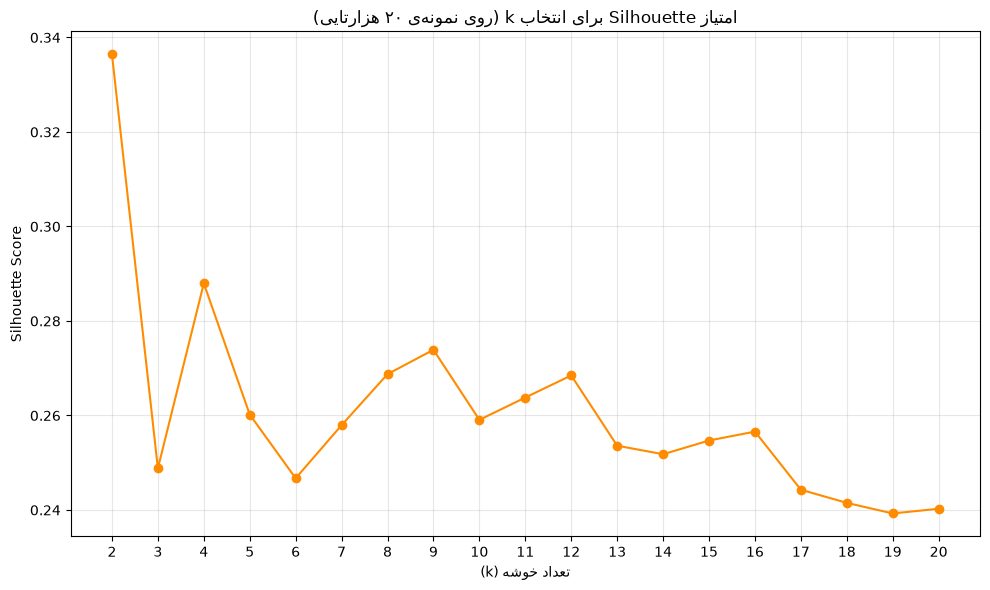

بهترین k بر اساس Silhouette: 2


In [20]:
sample_idx = np.random.RandomState(42).choice(X_scaled.shape[0], size=20000, replace=False)
X_sample = X_scaled[sample_idx]

silhouette_scores = []
k_range_sil = range(2, 21)  # Silhouette برای k=1 تعریف‌نشده

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_sample = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"k={k:2d} -> Silhouette={score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(list(k_range_sil), silhouette_scores, marker="o", color="darkorange")
plt.xlabel("تعداد خوشه (k)")
plt.ylabel("Silhouette Score")
plt.title("امتیاز Silhouette برای انتخاب k (روی نمونه‌ی ۲۰ هزارتایی)")
plt.xticks(list(k_range_sil))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k_silhouette = list(k_range_sil)[np.argmax(silhouette_scores)]
print("بهترین k بر اساس Silhouette:", best_k_silhouette)

<div dir="rtl">

### تحلیل جامع و تخصصی شاخص سیلوئت (Silhouette Analysis) برای انتخاب $k$

* **تحلیل روند تغییرات شاخص:**

  * **بیشینه مطلق ($k=2$ با امتیاز $0.3364$):** بالاترین مقدار عددی در $k=2$ ثبت شده است

  * **قله‌های محلی (Local MAX):** با عبور از $k=2$، منحنی افت کرده و سپس دو قله محلی مشخص در **$k=4$** (با امتیاز $0.2880$) و **$k=9$** (با امتیاز $0.2739$) تشکیل می‌دهد

### علت ریاضی و مفهومی بالاتر بودن امتیاز در $k=2$

۱. **ماهیت فرمول Silhouette روی داده‌های پیوسته:**  
شاخص سیلوئت هم‌زمان **تراکم درون‌خوشه‌ای** و **فاصله بین‌خوشه‌ای** را می‌سنجد. در متغیرهای پیوسته بازار مسکن (مانند قیمت، متراژ و موقعیت جغرافیایی)، وقتی داده‌ها فقط به ۲ بخش کلی تقسیم می‌شوند، میانگین فاصله بین دو مرکز خوشه در بیشترین حالت خود قرار می‌گیرد. در نتیجه، فرمول ریاضی سیلوئت به صورت طبیعی بیشترین امتیاز را به تفکیک اولیه ($k=2$) اختصاص می‌دهد.

۲. **تداخل مرزی با افزایش تعداد خوشه‌ها:**  
با افزایش تعداد خوشه‌ها، مرز میان دسته‌ها شلوغ‌تر شده و برخی داده‌ها در فواصل مرزی نزدیک به یکدیگر قرار می‌گیرند که این امر موجب کاهش طبیعی امتیاز سیلوئت در $k$های بالاتر می‌شود.

### چرا $k=2$ برای مدل‌سازی بازار املاک مناسب نیست؟

* **عدم کاربرد عملیاتی (Lack of Business Value):**  
دسته‌بندی کل آگهی‌های املاک کشور تنها به ۲ گروه کلی (مثلاً «ارزان/کوچک» و «گران/بزرگ»)، هیچ دید عمیق یا بخش‌بندی کاربردی از ساختار بازار (نظیر املاک لوکس، متراژ متوسط، اقتصادی، ویلایی یا تجاری) ارائه نمی‌دهد.

* **رویکرد استاندارد تحلیلی:**  
در مسائل تحلیلی داده‌های واقعی، هرگاه بیشینه مطلق شاخص سیلوئت در $k=2$ رخ دهد، تحلیل‌گران آن را به عنوان یک سوگیری هندسی در نظر گرفته و برای تصمیم‌گیری کاربردی، معطوف به **قله‌های محلی (Local Maxima)** در مقادیر بالاتر $k$ می‌شوند.

### 📌 نتیجه‌گیری و تلفیق با روش WCSS

با در نظر گرفتن قله‌های محلی شاخص سیلوئت (**$k=4$** و **$k=9$**) و ترکیب آن با خروجی روش WCSS و الگوریتم `KneeLocator` (**$k=6$**):

بازه‌ی **$k \in [4, 6]$** به عنوان محدوده بهینه انتخاب می‌شود. انتخاب عددی در این بازه (مانند **$k=6$**) تعادل استانداردی میان **شفافیت ریاضی خوشه‌ها** و **ارزش تحلیلی برای بخش‌بندی بازار مسکن** برقرار می‌سازد.

</div>